# A sustained type I IFN-neutrophil-IL-18 axis drives pathology during mucosal viral infection

The paper used Seurat and t-SNE. Here a Scanpy reproduction should aim for the same biological annotation, not identical cluster numbers or t-SNE coordinates.

## High-level steps

1. Prepare the environment and load all seven samples.
2. Filter cells with high mitochondrial counts.
3. Preprocess and cluster cells for QC.
4. Remove clusters with low median detected genes.
5. Repeat normalization and HVG selection on retained cells.
6. Regress total UMI, scale expression, and run PCA.
7. Build the neighbor graph and cluster again.
8. Plot t-SNE clusters and marker expression.
9. Review cell-type annotations and results.


## Import Python packages

In [67]:
from pathlib import Path
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

sc.settings.verbosity = 2
sc.set_figure_params(dpi=100, facecolor='white', frameon=False)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f'scanpy {sc.__version__}')
print(f'anndata {ad.__version__}')

scanpy 1.11.5
anndata 0.11.4


## Load Data

In [ ]:
import os

PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data" / "ifn-neutrophil" / "GSE161336" / "raw"

# In page 8, the authors mentioned that they used mock, HSV-1, and HSV-2. No mentioning exact d.p.i for figure 3ab.
SAMPLES = {
    'GSM4905024': {'prefix': 'GSM4905024_mock_', 'condition': 'mock', 'dpi': None},
    'GSM4905025': {'prefix': 'GSM4905025_d1_HSV-1_', 'condition': 'HSV-1', 'dpi': 1},
    'GSM4905026': {'prefix': 'GSM4905026_d1_HSV-2_', 'condition': 'HSV-2', 'dpi': 1},
    'GSM4905027': {'prefix': 'GSM4905027_d3_HSV-1_', 'condition': 'HSV-1', 'dpi': 3},
    'GSM4905028': {'prefix': 'GSM4905028_d3_HSV-2_', 'condition': 'HSV-2', 'dpi': 3},
    'GSM4905029': {'prefix': 'GSM4905029_d5_HSV-1_', 'condition': 'HSV-1', 'dpi': 5},
    'GSM4905030': {'prefix': 'GSM4905030_d5_HSV-2_', 'condition': 'HSV-2', 'dpi': 5},
}


def load_10x_sample(sample_id: str, details: dict) -> ad.AnnData:
    adata = sc.read_10x_mtx(
        DATA_DIR,
        prefix=details['prefix'],
        var_names='gene_symbols',
        make_unique=True,
    )
    adata.obs_names = [f'{sample_id}_{barcode}' for barcode in adata.obs_names]
    adata.obs['sample'] = sample_id
    adata.obs['condition'] = details['condition']
    adata.obs['dpi'] = details['dpi']
    return adata

adatas = {sample_id: load_10x_sample(sample_id, details) for sample_id, details in SAMPLES.items()}
print('Loaded cells by sample:', {key: value.n_obs for key, value in adatas.items()})
adata = ad.concat(adatas, label='sample_id', index_unique=None, merge='same')
adata.obs['condition'] = pd.Categorical(adata.obs['condition'], categories=['mock', 'HSV-1', 'HSV-2'])

print(f"Number of cells: {adata.n_obs}")
print(f"Number of genes: {adata.n_vars}")


## QC: mitochondrial counts


In [ ]:
# tmp folder for saving qc calculation results
QC_DIR = PROJECT_DIR / 'tmp' / 'python-cluster-qc'
QC_DIR.mkdir(parents=True, exist_ok=True)

# In paper page 18: remove cells with >5% mitochondrial counts.
# Keep low-gene cells here so the initial clustering can identify low-quality groups.
adata.layers['counts'] = adata.X.copy()
adata.var['mt'] = adata.var_names.str.replace(r'^mm10_', '', regex=True).str.lower().str.startswith('mt-')
n_cells_before_qc = adata.n_obs


sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], log1p=False, inplace=True)
mt_keep = adata.obs['pct_counts_mt'] <= 5
input_qc = adata.obs.copy()
input_qc['passes_mitochondrial_qc'] = mt_keep
input_qc.to_csv(QC_DIR / 'input_cell_qc.csv')
adata = adata[mt_keep].copy()
print(f'Mitochondrial QC: {n_cells_before_qc:,} -> {adata.n_obs:,} cells')


Mitochondrial QC: 25,233 -> 20,795 cells


## QC: Initial clustering for removing low gene counts


In [ ]:
# Initial QC-clustering parameters are not reported in the paper.
# This exploratory pass uses log-normalization/scaling without UMI regression;
# the final analysis below applies Seurat negative-binomial regression after QC.
# Will apply a different set of parameters for the final analysis.
QC_N_HVGS = 3000
QC_N_PCS = 30
QC_N_NEIGHBORS = 15
QC_RESOLUTION = 0.5


qc_adata = adata.copy()  # Keep adata.X as unmodified counts for the final analysis.
sc.pp.normalize_total(qc_adata, target_sum=1e4)
sc.pp.log1p(qc_adata)
sc.pp.highly_variable_genes(qc_adata, flavor='seurat', n_top_genes=QC_N_HVGS)
qc_adata = qc_adata[:, qc_adata.var['highly_variable']].copy()
sc.pp.scale(qc_adata, max_value=10)
sc.tl.pca(qc_adata, n_comps=50, svd_solver='arpack', random_state=RANDOM_SEED)
sc.pp.neighbors(qc_adata, n_pcs=QC_N_PCS, n_neighbors=QC_N_NEIGHBORS, random_state=RANDOM_SEED)
sc.tl.leiden(qc_adata, resolution=QC_RESOLUTION, key_added='qc_cluster',
             random_state=RANDOM_SEED, flavor='igraph', n_iterations=2)

adata.obs['qc_cluster'] = qc_adata.obs['qc_cluster'].copy()
print(f'Initial QC clusters: {adata.obs["qc_cluster"].nunique()}')
del qc_adata


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)


/home/jerry/dev/jerry-paper-exercise/.venv/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:07)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:01)
running Leiden clustering
    finished (0:00:00)
Initial QC clusters: 20


## QC: Remove low-quality clusters


In [ ]:
# Gap vs paper (PDF p. 18): it removed three low-gene clusters but does not
# specify the cluster statistic or initial clustering settings. We use median detected genes <500;

# 1. Set the cutoff and summarize each cluster
QC_MIN_MEDIAN_GENES = 500
cluster_qc = adata.obs.groupby('qc_cluster', observed=True).agg(
    n_cells=('n_genes_by_counts', 'size'),
    median_genes=('n_genes_by_counts', 'median'),
    mean_genes=('n_genes_by_counts', 'mean'),
    fraction_below_500=('n_genes_by_counts', lambda x: (x < 500).mean()),
    median_total_counts=('total_counts', 'median'),
    median_mt_pct=('pct_counts_mt', 'median'),
)

# 2. Identify low-quality clusters and cells to keep
cluster_qc['remove_cluster'] = cluster_qc['median_genes'] < QC_MIN_MEDIAN_GENES
low_quality_clusters = cluster_qc.index[cluster_qc['remove_cluster']].tolist()
keep_cluster = ~adata.obs['qc_cluster'].isin(low_quality_clusters)

# 3. Display cluster decisions
print(cluster_qc.to_string())
print(f'Low-quality clusters to remove: {low_quality_clusters}')

# 4. Count removed and retained cells
qc_summary = pd.DataFrame([{
    'cells_before_qc': n_cells_before_qc,
    'cells_removed_high_mt': int((~mt_keep).sum()),
    'cells_after_mt_filter': adata.n_obs,
    'low_quality_clusters_removed': len(low_quality_clusters),
    'cells_removed_by_cluster': int((~keep_cluster).sum()),
    'cells_retained': int(keep_cluster.sum()),
}])

# 5. Filter cells and verify that raw counts are preserved
adata = adata[keep_cluster].copy()
assert adata.raw is None and (adata.X != adata.layers['counts']).nnz == 0

# 6. Summarize each sample
qc_by_sample = input_qc.groupby('sample', observed=True).size().to_frame('cells_before')
qc_by_sample['cells_retained'] = adata.obs.groupby('sample', observed=True).size().reindex(qc_by_sample.index, fill_value=0)

# 7. Display the final QC summaries
print(qc_summary.to_string(index=False))
print(qc_by_sample.to_string())


            n_cells  median_genes   mean_genes  fraction_below_500  median_total_counts  median_mt_pct  remove_cluster
qc_cluster                                                                                                            
0              1003        2636.0  2702.833500            0.002991               9616.0       3.349136           False
1               952        2686.0  2776.281513            0.000000               9727.5       2.796053           False
2              3799        1259.0  1363.588049            0.011319               4733.0       0.247088           False
3              1336          96.0   183.570359            0.942365                147.0       0.438295            True
4              3204        1252.5  1417.945069            0.029963               5523.5       0.270740           False
5               958         534.0   615.962422            0.416493                850.5       1.048722           False
6              1560         693.0  1261.991026  

## Normalize counts and select highly variable genes

In [ ]:
# Also in paper page 18. The paper normalized to 10,000 counts per cell, log-transformed the data,
# and used the top 3,000 variable genes for dimensionality reduction.

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

sc.pp.highly_variable_genes(
    adata,
    flavor='seurat',
    n_top_genes=3000, # paper states that PCA was performed using the top 3,000 most variable genes.
    subset=False,
)

n_hvgs = int(adata.var['highly_variable'].sum())
print(f'Highly variable genes selected: {n_hvgs:,}')


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
Highly variable genes selected: 3,000


## Linear UMI regression, scaling, and PCA
Uses Scanpy linear regression on log-normalized expression; differs from the paper's negative-binomial regression.


regressing out ['total_counts']
    sparse input is densified and may lead to high memory use
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:05)


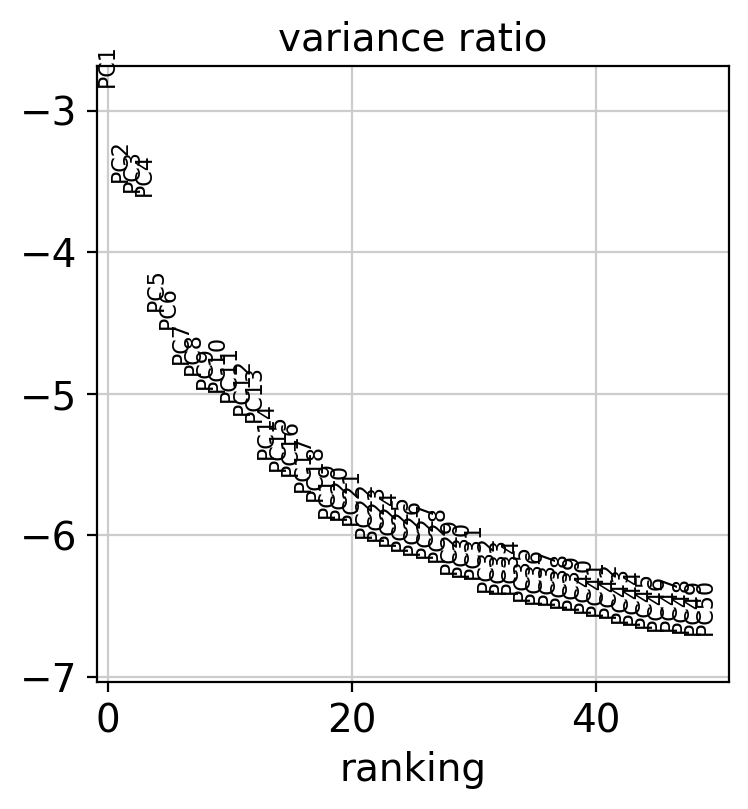

In [ ]:
# A Gap between python scanpy and R Seurat. In the paper, the authors used R-Seurat
# which applies negative-binomial regression to regress the total UMI counts from the HVGs.
# Here, we use the Scanpy linear regression to approximate the paper's method.

# 1. Select HVGs and restore their log-normalized expression.
adata = adata[:, adata.var['highly_variable']].copy()
adata.X = adata.raw[:, adata.var_names].X.copy()

# 2. Regress total UMI, then scale residuals.
sc.pp.regress_out(adata, keys=['total_counts'], n_jobs=4)
sc.pp.scale(adata, max_value=10)
adata.uns['regression'] = {'method': 'Scanpy linear regression',
                           'covariate': 'total UMI across all genes', 'scale_max': 10}

# 3. Run PCA on the scaled residuals.
sc.tl.pca(adata, n_comps=50, svd_solver='arpack', random_state=RANDOM_SEED)
FIGURE_DIR = PROJECT_DIR / 'figures' / 'ifn-neutrophil' / 'py-scanpy'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, show=False)
plt.savefig(FIGURE_DIR / 'pca_variance_ratio.png', dpi=300, bbox_inches='tight')
plt.show()


## Build the neighbor graph and identify exploratory cell clusters

In [ ]:
# The paper used a KNN graph and tested Seurat resolutions from 0.1 to 1.5,
# but did not report its final resolution or PC count. The settings below are
# exploratory Scanpy choices, not recovered paper parameters. Leiden is not
# established as the original Seurat algorithm. Cluster count is not a target.
N_PCS = 40
N_NEIGHBORS = 30
LEIDEN_RESOLUTION = 0.4  # exploratory choice; not selected to match 17 clusters

sc.pp.neighbors(
    adata,
    n_neighbors=N_NEIGHBORS,
    n_pcs=N_PCS,
    random_state=RANDOM_SEED,
)
sc.tl.leiden(
    adata,
    resolution=LEIDEN_RESOLUTION,
    key_added='leiden',
    random_state=RANDOM_SEED,
    flavor='igraph',
    n_iterations=2,
)

cluster_sizes = adata.obs['leiden'].value_counts().sort_index()
print(f'Clusters identified: {adata.obs["leiden"].nunique()}')
cluster_sizes.to_frame('n_cells')


computing neighbors
    using 'X_pca' with n_pcs = 40
    finished (0:00:01)
running Leiden clustering
    finished (0:00:00)
Clusters identified: 14


,n_cells
leiden,
0,1262
1,4079
2,173
3,1485
4,945
5,479
6,726
7,2937
8,1234


## Figure 3A: t-SNE visualization of cell clusters

computing tSNE
    using 'X_pca' with n_pcs = 40
    using sklearn.manifold.TSNE
    finished (0:00:19)


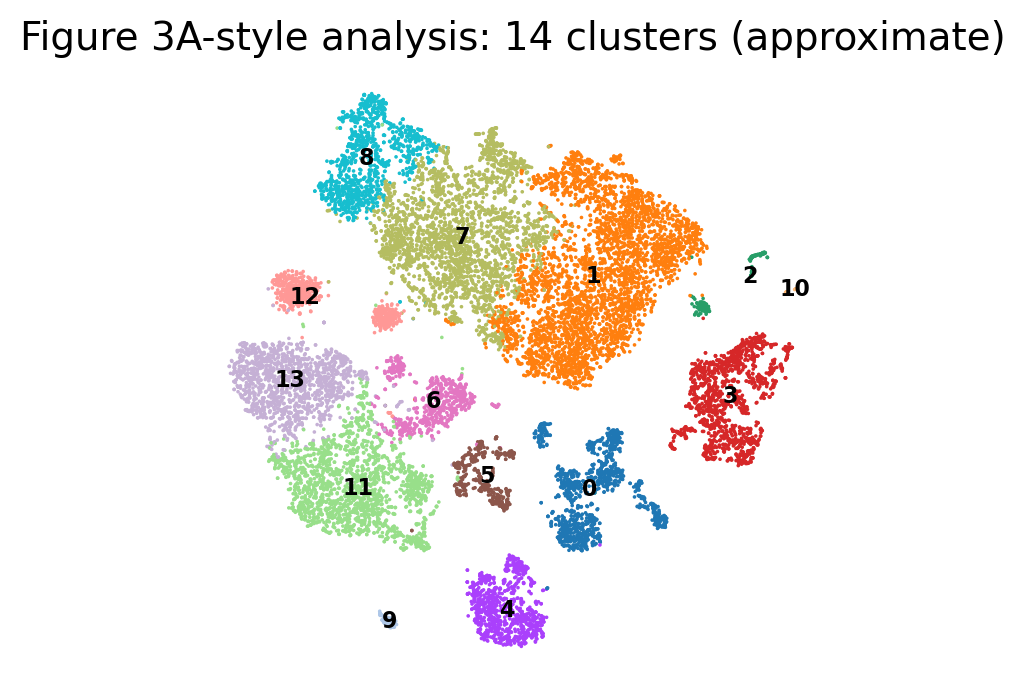

In [ ]:
# Place the same cluster IDs on every gene-expression panel.
from matplotlib import patheffects
from matplotlib.collections import PathCollection

def label_tsne_clusters(fig, adata):
    coordinates = pd.DataFrame(adata.obsm['X_tsne'], columns=['x', 'y'],
                               index=adata.obs_names)
    centers = coordinates.groupby(adata.obs['leiden'], observed=True).median()
    for ax in fig.axes:
        if any(isinstance(collection, PathCollection) for collection in ax.collections):
            for cluster, center in centers.iterrows():
                ax.text(center.x, center.y, str(cluster), ha='center', va='center',
                        fontsize=8, fontweight='bold', color='black',
                        path_effects=[patheffects.withStroke(linewidth=2, foreground='white')])

sc.tl.tsne(
    adata,
    n_pcs=N_PCS,
    random_state=RANDOM_SEED,
)

FIGURE_DIR = PROJECT_DIR / 'figures' / 'ifn-neutrophil' / 'py-scanpy'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig3a = sc.pl.tsne(
    adata,
    color='leiden',
    legend_loc='on data',
    legend_fontsize=8,
    frameon=False,
    title=f'Figure 3A-style analysis: {adata.obs.leiden.nunique()} clusters (approximate)',
    show=False,
    return_fig=True,
)
fig3a.savefig(FIGURE_DIR / 'figure3A_tsne_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


## Figure 3B: identify neutrophil clusters with S100a8 and Csf3r

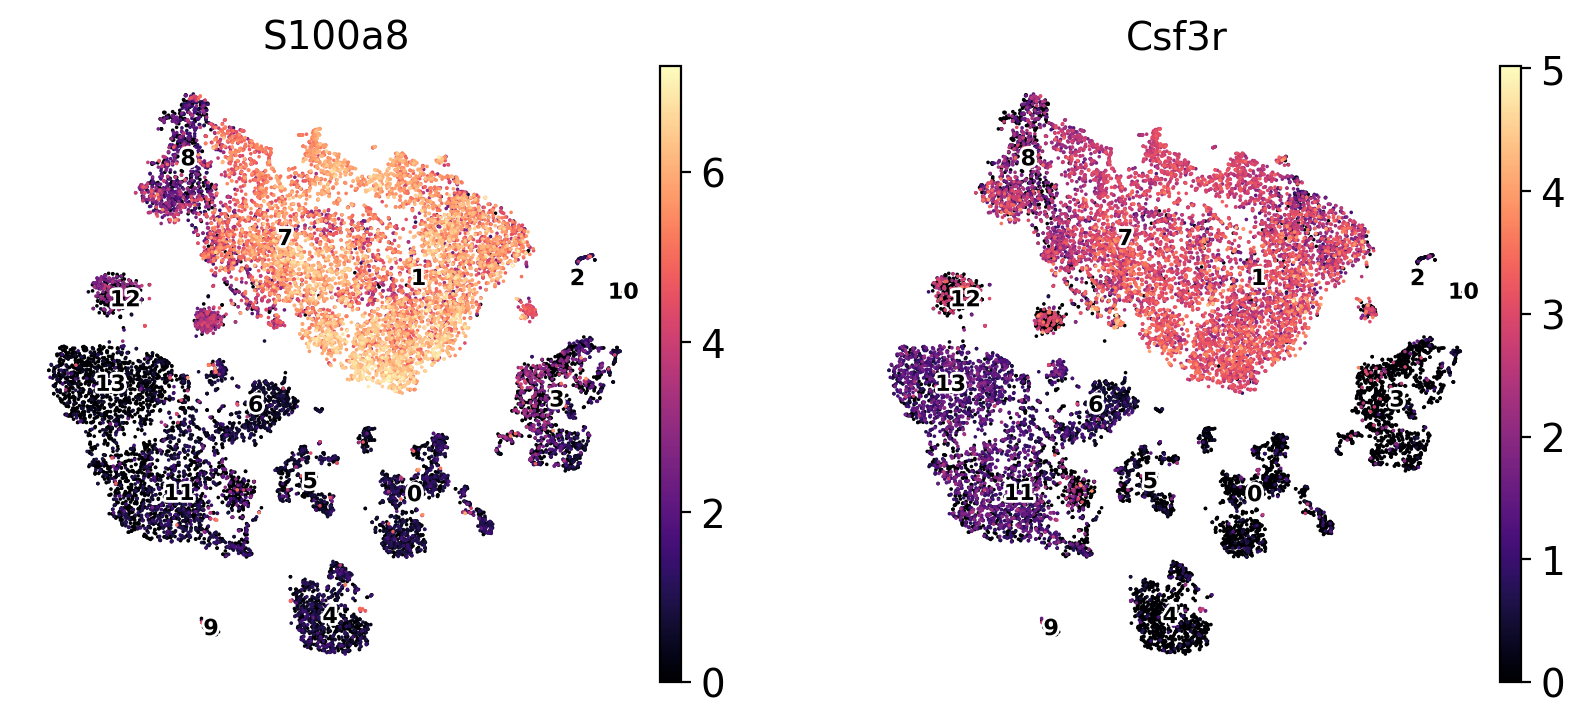

,S100a8,Csf3r,mean_marker_expression
leiden,,,
1,5.349244,2.575138,3.962191
7,4.758444,2.473812,3.616128
8,2.163198,1.487820,1.825509
2,2.554550,0.847606,1.701078
12,1.676114,0.940514,1.308314
10,1.481385,0.405191,0.943288
13,0.174643,0.906125,0.540384
11,0.385271,0.677910,0.531591
3,0.836503,0.093967,0.465235


In [ ]:
# Full color range preserves rare markers whose 99th percentile is zero.
NEUTROPHIL_MARKERS = {
    'S100a8': 'mm10_S100a8',
    'Csf3r': 'mm10_Csf3r',
}
marker_vars = list(NEUTROPHIL_MARKERS.values())
missing_markers = [gene for gene in marker_vars if gene not in adata.raw.var_names]
if missing_markers:
    raise KeyError(f'Markers missing from adata.raw: {missing_markers}')

fig3b = sc.pl.tsne(
    adata,
    color=marker_vars,
    title=list(NEUTROPHIL_MARKERS),
    use_raw=True,
    cmap='magma',
    vmin=0, vmax=None, sort_order=True,
    ncols=2,
    frameon=False,
    show=False,
    return_fig=True,
)
label_tsne_clusters(fig3b, adata)
fig3b.savefig(FIGURE_DIR / 'figure3B_neutrophil_markers.png', dpi=300, bbox_inches='tight')
plt.show()

marker_by_cell = sc.get.obs_df(
    adata,
    keys=['leiden', *marker_vars],
    use_raw=True,
)
marker_summary = (
    marker_by_cell.rename(columns={value: key for key, value in NEUTROPHIL_MARKERS.items()})
    .groupby('leiden', observed=True)[list(NEUTROPHIL_MARKERS)]
    .mean()
    .assign(mean_marker_expression=lambda table: table.mean(axis=1))
    .sort_values('mean_marker_expression', ascending=False)
)
marker_summary


## Figure 3A: candidate markers for the circled cell groups

### Extra: Marker evidence for the new clusters

After checking mouse dataset from PanglaoDB, these are useful starting markers for other clusters. Only **S100a8/Csf3r** are specified by the paper. Other panels are candidate annotation markers, not assignments to the paper's numbered clusters.

| Broad group | Cell type | Typical marker genes |
|---|---|---|
| Myeloid | **Neutrophils** | **S100a8, S100a9, Csf3r, Ly6g** |
| Myeloid | Monocytes | Lyz2, Lst1, Ccr2, Ly6c2 |
| Myeloid | Macrophages | Adgre1 (*F4/80*), Csf1r, C1qa, C1qb |
| Myeloid | Dendritic cells | Itgax, H2-Ab1, Cd74; subtype markers help distinguish them |
| Lymphocytes | **T cells** | **Cd3d, Cd3e, Trac** |
| Lymphocytes | **B cells** | **Cd79a, Cd79b, Ms4a1, Cd19** |
| Lymphocytes | NK cells | Nkg7, Ncr1, Klrd1; little/no Cd3d or Cd3e |
| Epithelial | **Epithelial cells** | **Epcam, Krt8, Krt18, Krt19** |
| Epithelial | Basal/squamous epithelial cells | Krt5, Krt14, Trp63 |

### Selecte here

| Group | Selected markers |
|---|---|
| PMN | S100a8, Csf3r |
| Other myeloid | Csf1r, Fcgr1 (monocytes/macrophages); Cd74, Flt3 (DC assessment) |
| Epithelial | Epcam, Krt5, Krt14, Krt18 |
| Lymphocytes | Cd3d, Cd3e (T); Ncr1, Klrd1 (NK) |



PMN markers: S100a8, Csf3r


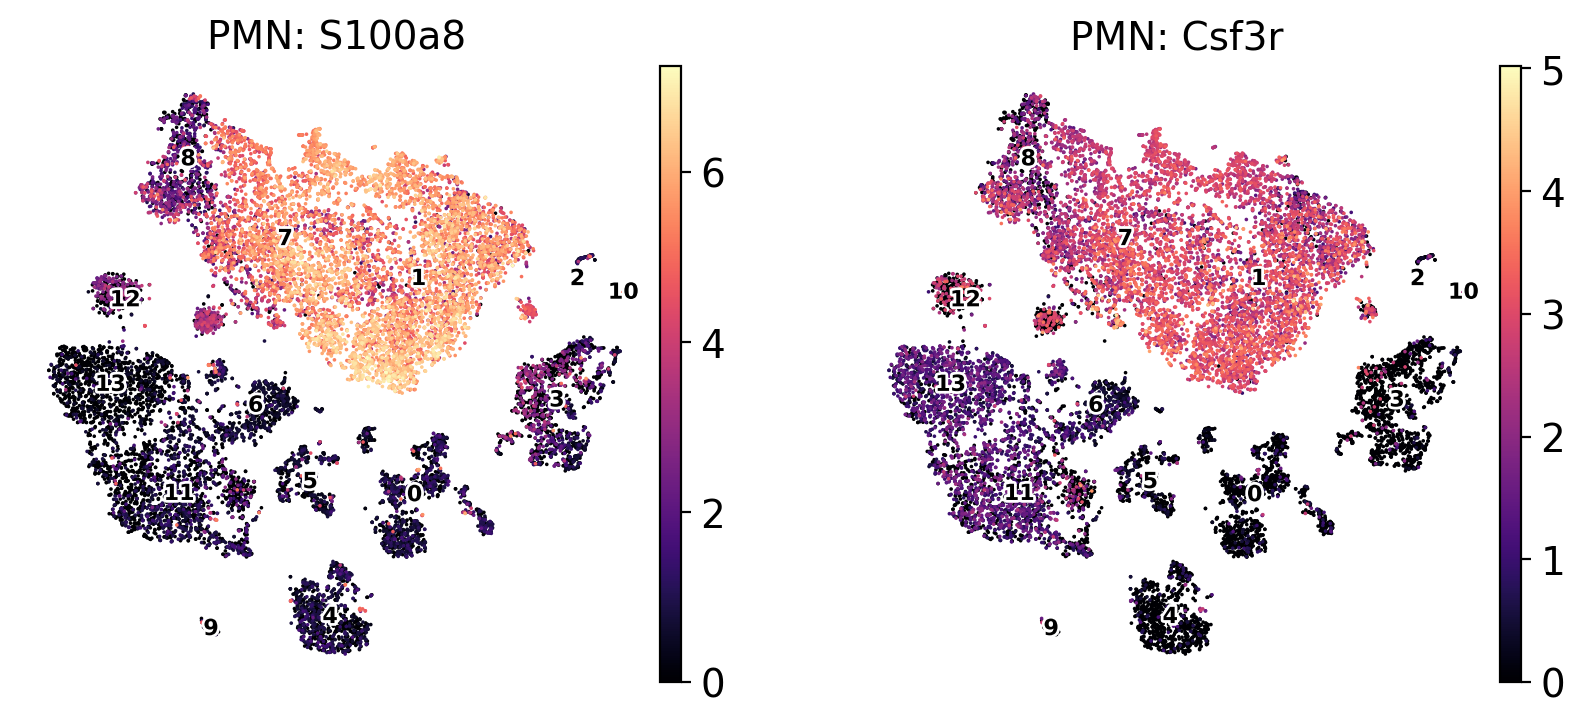

Other myeloid markers: Csf1r, Fcgr1, Cd74, Flt3


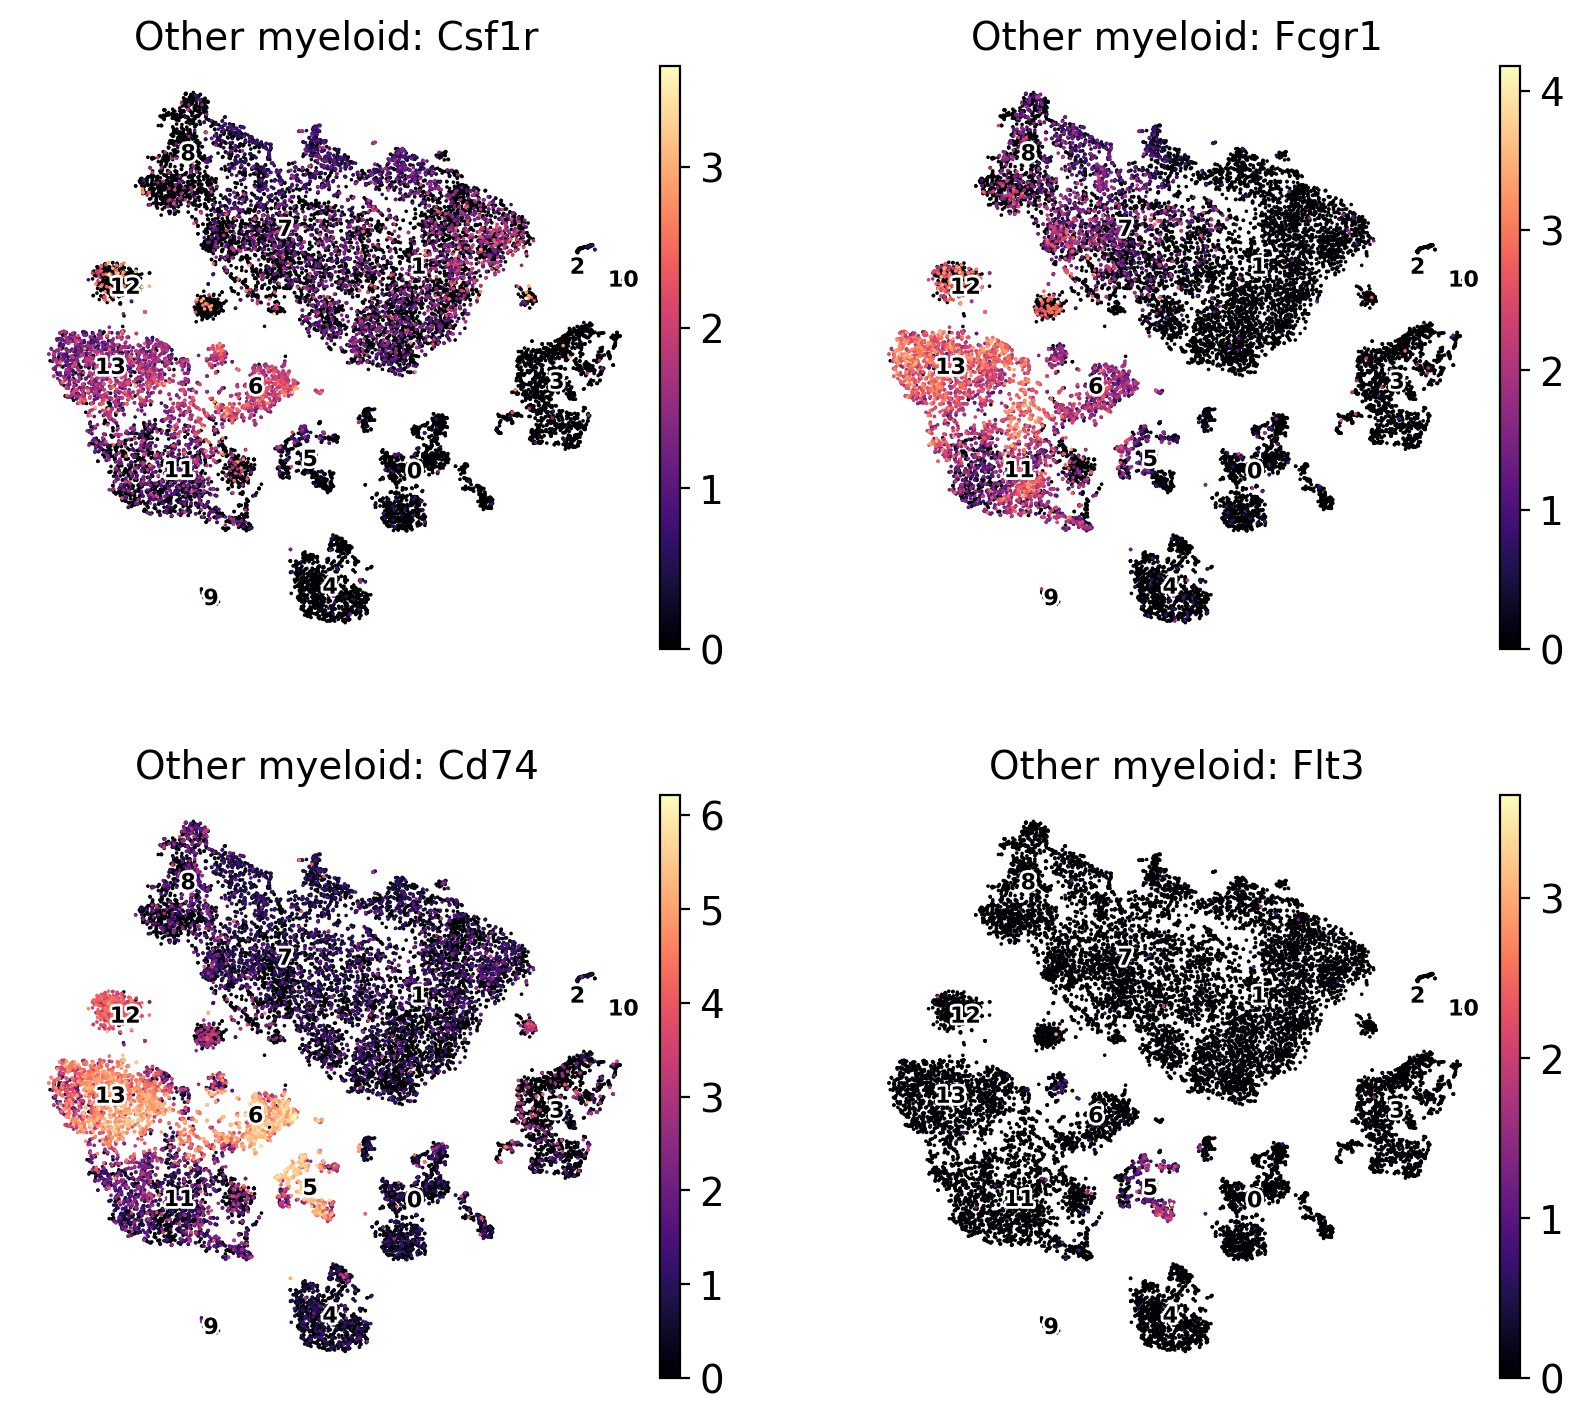

Epithelial markers: Epcam, Krt5, Krt14, Krt18


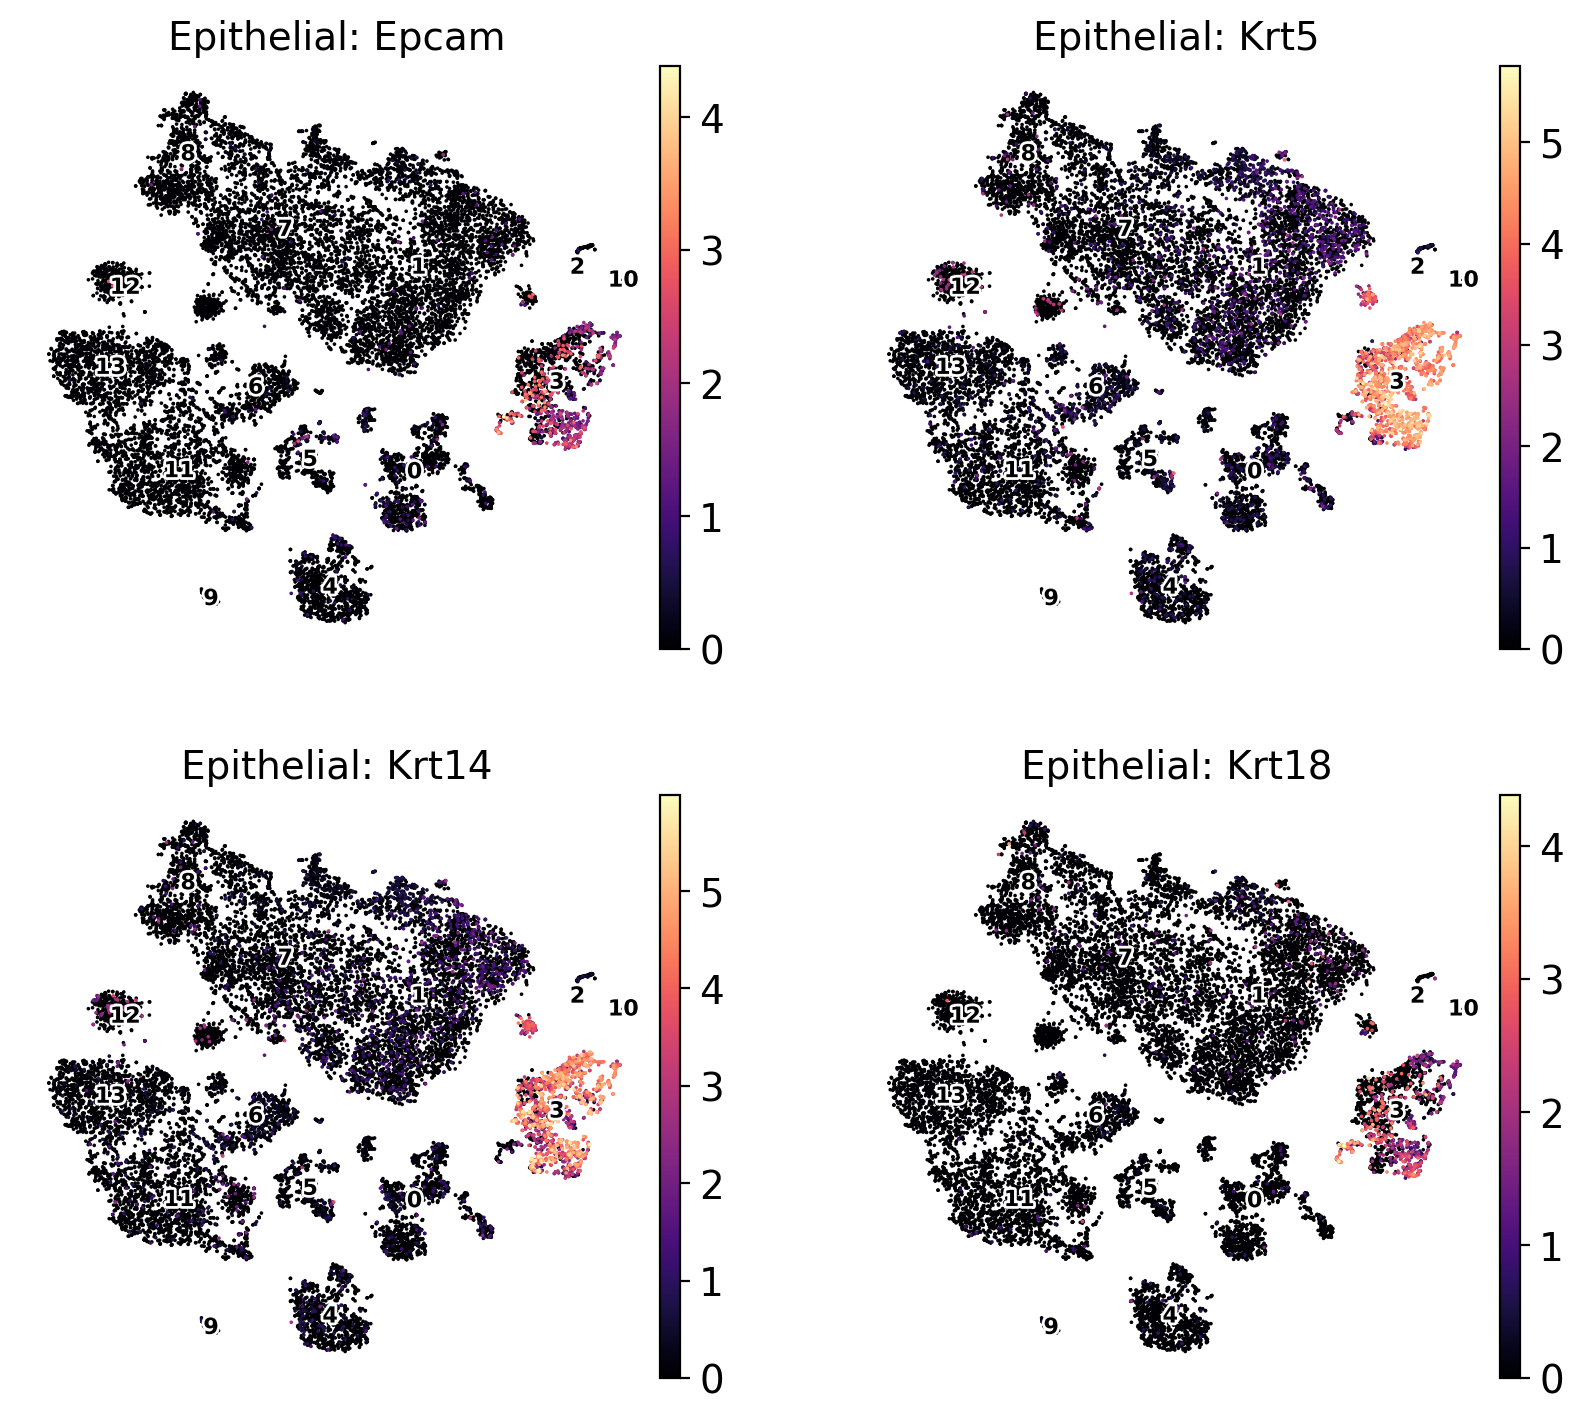

Lymphocytes markers: Cd3d, Cd3e, Ncr1, Klrd1


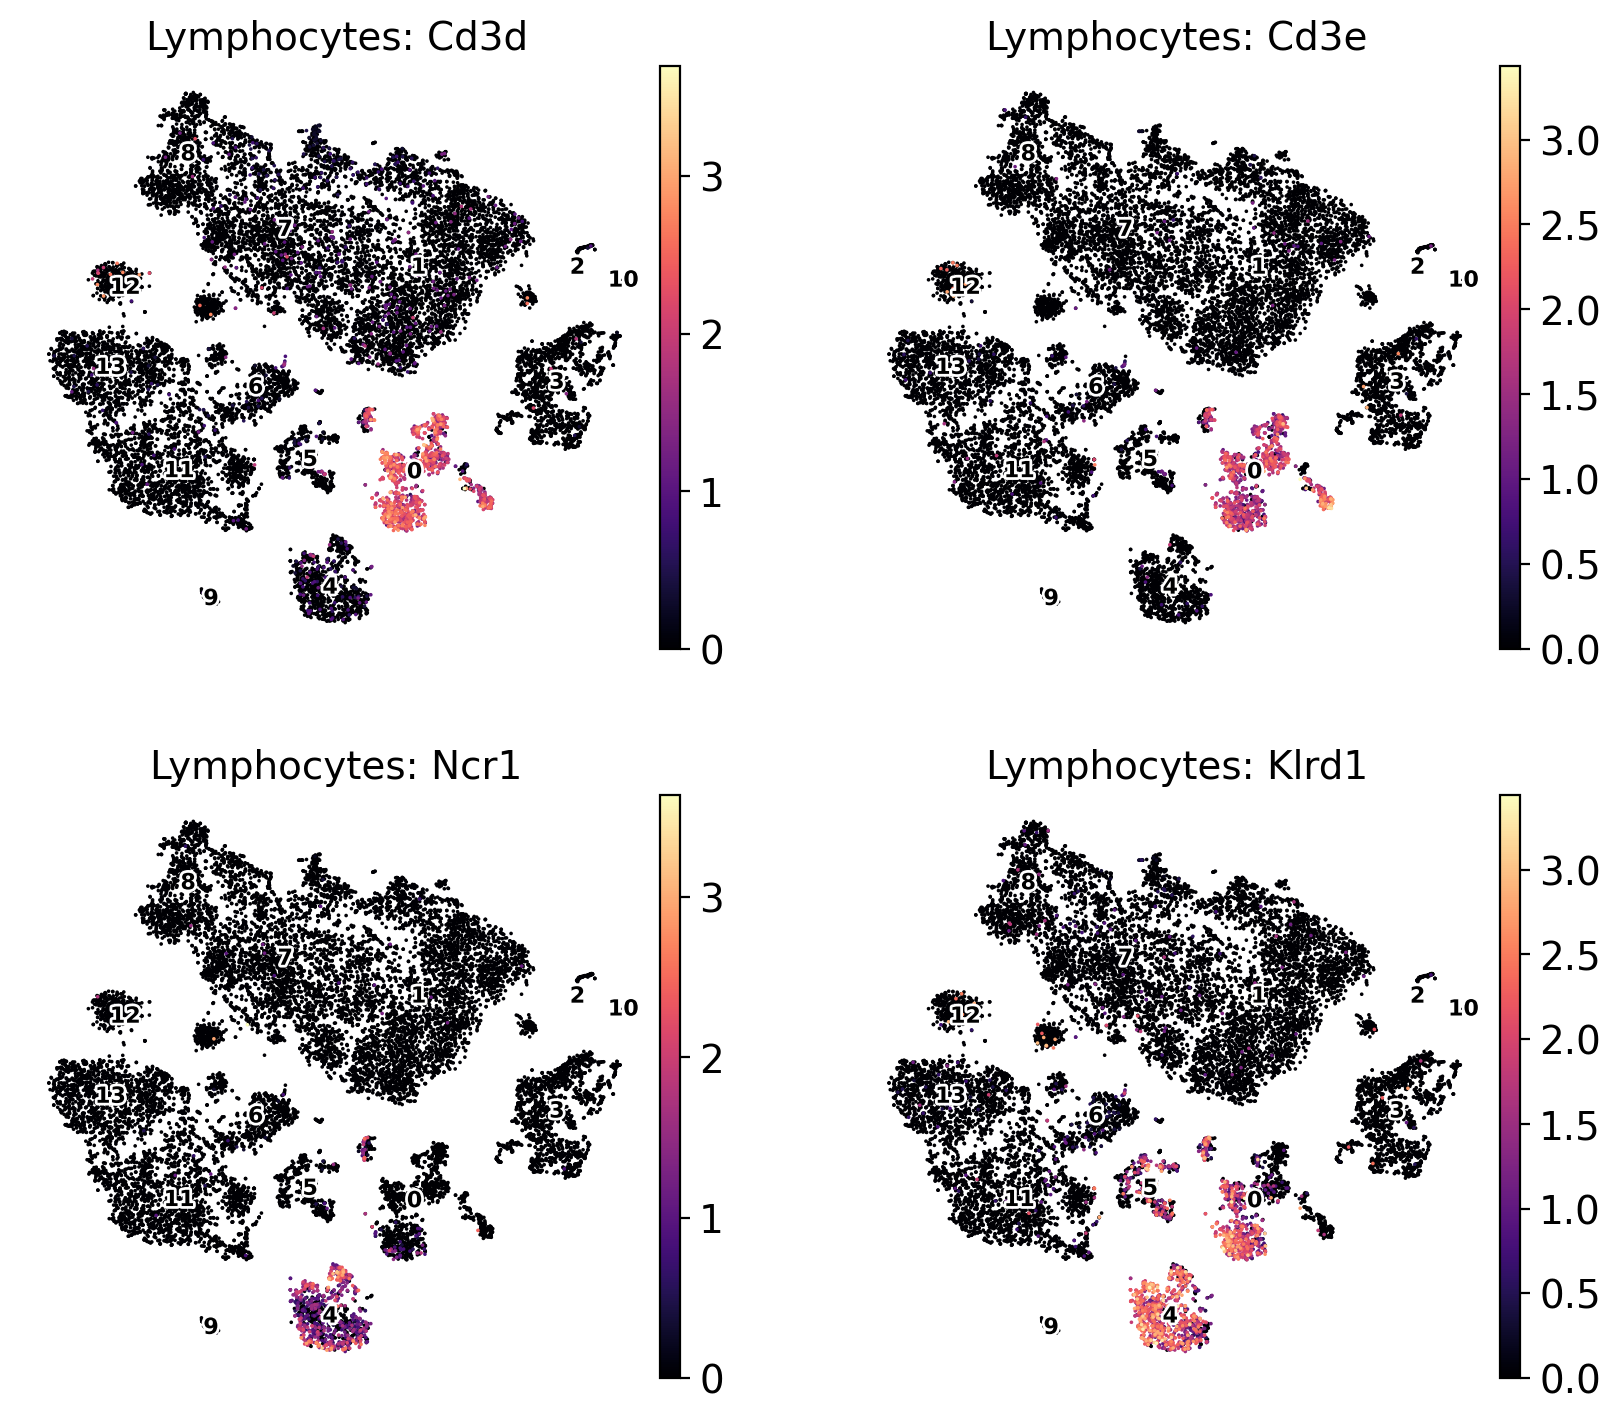

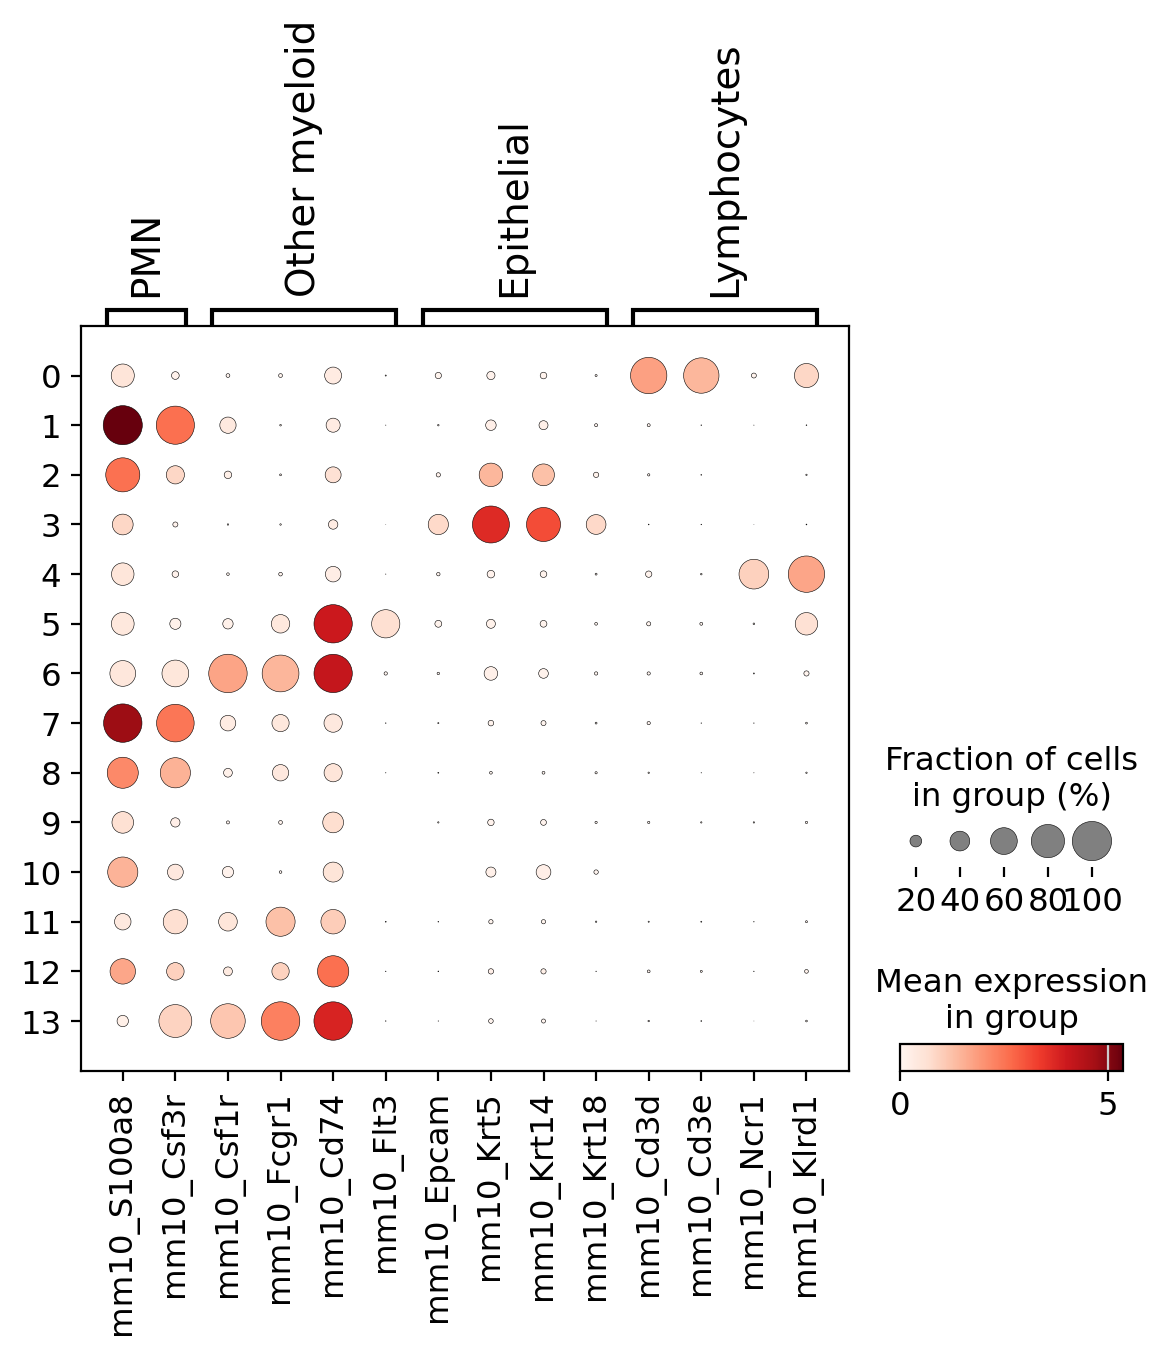

In [ ]:
# Full color range preserves rare markers whose 99th percentile is zero.
# Candidate markers for Figure 3A groups; only the PMN pair is paper-specified.
# Csf1r/Fcgr1 support monocytes/macrophages; Cd74/Flt3 support DC assessment.
# Cd74 is shared with B cells, so interpret the marker combinations together.
FIG3A_GROUP_MARKERS = {
    'PMN': ['S100a8', 'Csf3r'],
    'Other myeloid': ['Csf1r', 'Fcgr1', 'Cd74', 'Flt3'],
    'Epithelial': ['Epcam', 'Krt5', 'Krt14', 'Krt18'],
    'Lymphocytes': ['Cd3d', 'Cd3e', 'Ncr1', 'Klrd1'],
}

# Overlay individual genes on the same t-SNE coordinates, as in Figure 3B.
for group, genes in FIG3A_GROUP_MARKERS.items():
    print(f'{group} markers: {", ".join(genes)}', flush=True)
    fig = sc.pl.tsne(
        adata, color=['mm10_' + gene for gene in genes],
        title=[f'{group}: {gene}' for gene in genes],
        use_raw=True, cmap='magma', vmin=0, vmax=None, sort_order=True, ncols=2,
        frameon=False, show=False, return_fig=True,
    )
    label_tsne_clusters(fig, adata)
    filename = group.lower().replace(' ', '_')
    fig.savefig(FIGURE_DIR / f'figure3A_{filename}_markers.png',
                dpi=200, bbox_inches='tight')
    plt.show()

# Compare marker expression and expressing-cell fractions across our clusters.
group_features = {
    group: ['mm10_' + gene for gene in genes]
    for group, genes in FIG3A_GROUP_MARKERS.items()
}
dp = sc.pl.dotplot(
    adata, group_features, groupby='leiden', use_raw=True,
    return_fig=True, show=False,
)
dp.savefig(FIGURE_DIR / 'figure3A_group_marker_dotplot.png',
           dpi=200, bbox_inches='tight')
plt.show()


## Figure 3C: split the joint t-SNE by infection condition
Now in each panel shows only mock, HSV-1 or HSV-2 cells. Only mock and day-5 HSV cells are displayed. The embedding and clustering still use all seven samples. No reclustering is needed. Cell types are not the split variable.


Figure 3C: mock, 1,498 cells
Figure 3C: HSV-1, 1,752 cells
Figure 3C: HSV-2, 3,698 cells


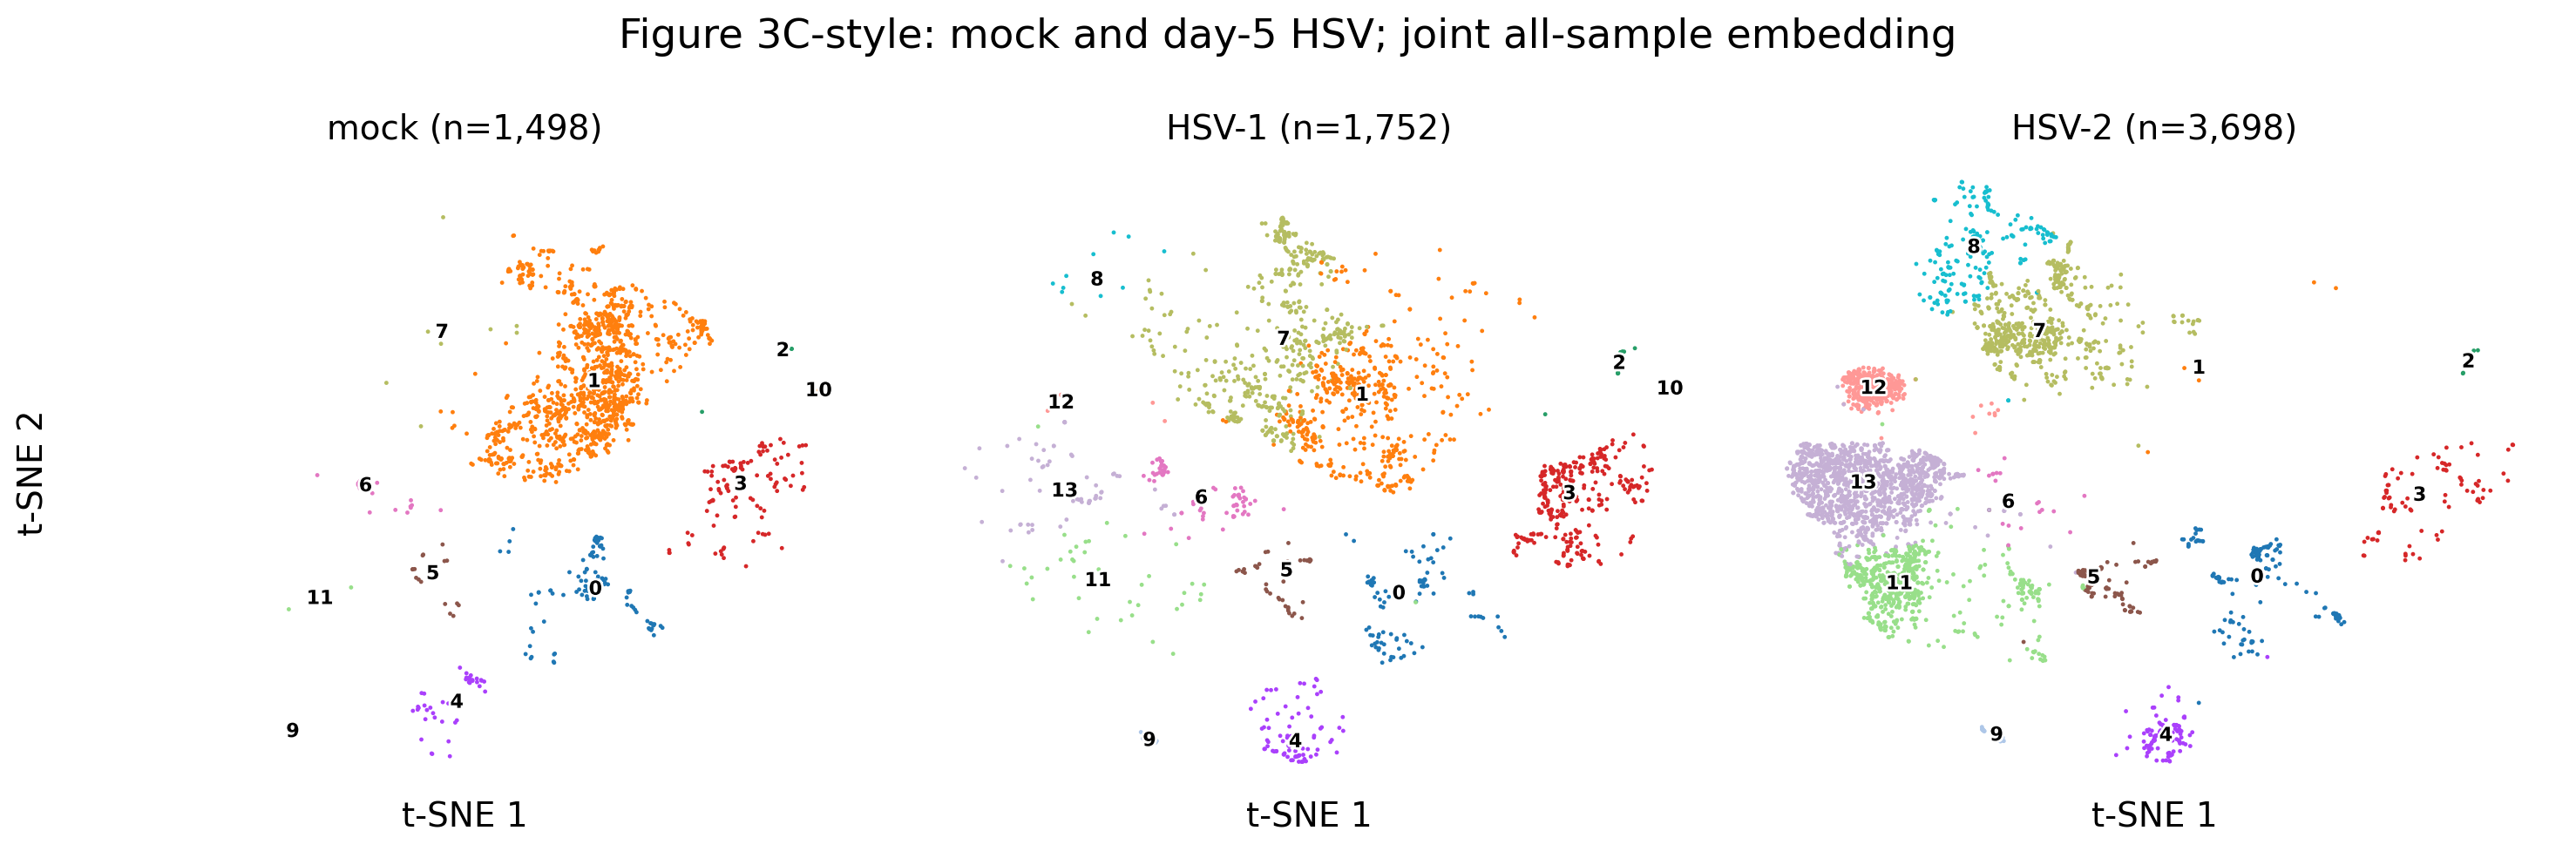

In [ ]:
# Split conditions without recomputing PCA, neighbors, clusters, or t-SNE.
display_cells = (adata.obs['condition'].eq('mock') | adata.obs['dpi'].eq(5)).to_numpy()
conditions = ['mock', 'HSV-1', 'HSV-2']
cluster_colors = dict(zip(adata.obs['leiden'].cat.categories, adata.uns['leiden_colors']))
xy = adata.obsm['X_tsne']
fig3c, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, condition in zip(axes, conditions):
    mask = adata.obs['condition'].eq(condition).to_numpy() & display_cells
    subset = adata[mask]
    colors = [cluster_colors[cluster] for cluster in subset.obs['leiden']]
    ax.scatter(xy[mask, 0], xy[mask, 1], c=colors, s=3, linewidths=0, rasterized=True)
    centers = pd.DataFrame(xy[mask], columns=['x', 'y'], index=subset.obs_names)
    centers = centers.groupby(subset.obs['leiden'], observed=True).median()
    for cluster, center in centers.iterrows():
        ax.text(center.x, center.y, str(cluster), ha='center', va='center',
                fontsize=8, fontweight='bold', color='black',
                path_effects=[patheffects.withStroke(linewidth=2, foreground='white')])
    ax.set_title(f'{condition} (n={mask.sum():,})')
    ax.set_xlabel('t-SNE 1')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    print(f'Figure 3C: {condition}, {mask.sum():,} cells', flush=True)

axes[0].set_ylabel('t-SNE 2')
fig3c.suptitle('Figure 3C-style: mock and day-5 HSV; joint all-sample embedding')
fig3c.tight_layout()
fig3c.savefig(FIGURE_DIR / 'figure3C_tsne_by_condition.png', dpi=300, bbox_inches='tight')
plt.show()


## Figure 3D: IFN-alpha response score
Uses the downloaded mouse MSigDB **HALLMARK_INTERFERON_ALPHA_RESPONSE** (MM3877) snapshot, matched to full-gene log-normalized expression. Scanpy subtracts expression-matched control-gene expression from gene-set expression. This is an approximation: the paper's exact scoring settings and historical gene-list version are unknown. Only mock and day-5 HSV cells are displayed. Scoring and the embedding still use all seven samples. Shared color scale, original t-SNE coordinates.


IFN-alpha genes matched: 89/94
Unmatched symbols: ['Cxcl11', 'Ifi30', 'Mx2', 'Tent5a', 'Wars1']
computing score 'IFN_alpha_score'
    finished (0:00:00)


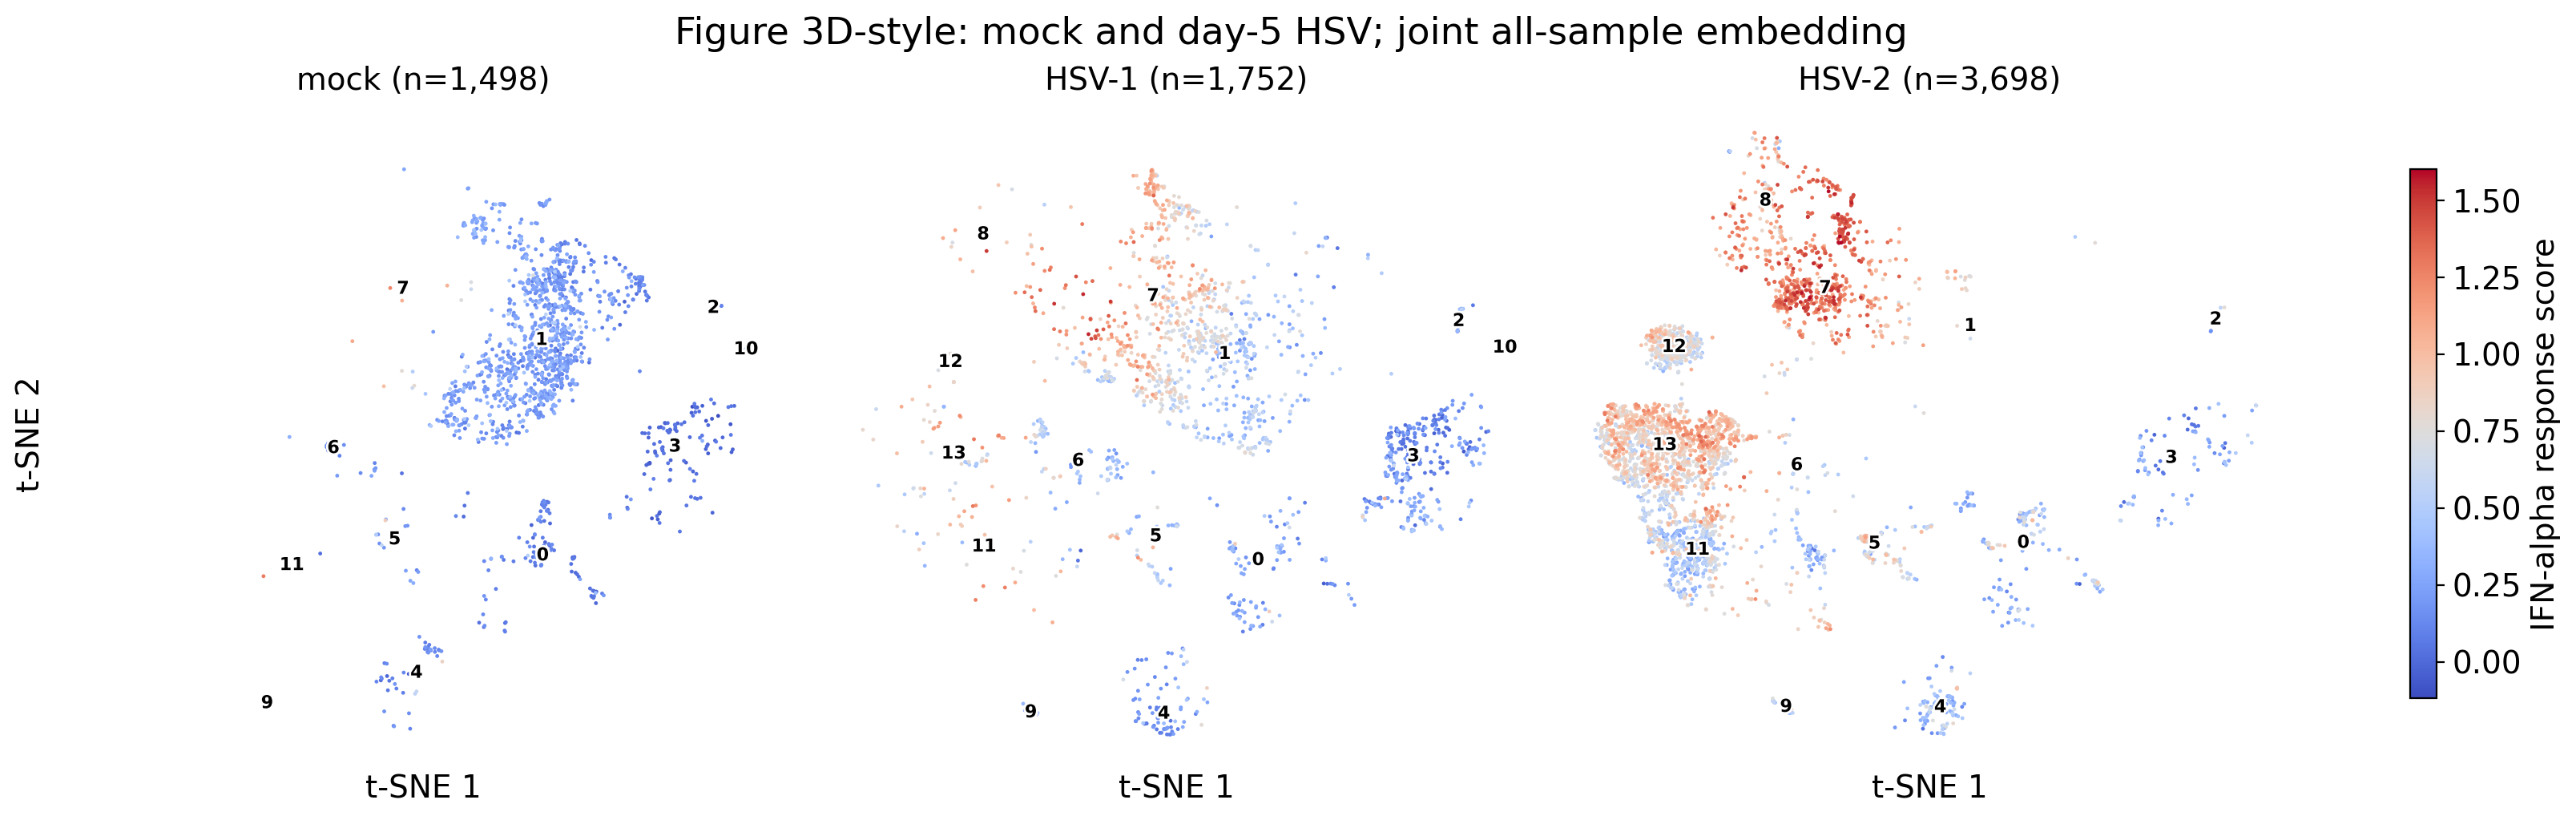

In [ ]:
# Score the full log-normalized matrix once, before splitting conditions.
import json
SOURCE_DIR = PROJECT_DIR / 'data' / 'ifn-neutrophil' / 'paper-source'
gene_set = json.loads((SOURCE_DIR / 'HALLMARK_INTERFERON_ALPHA_RESPONSE.mouse.json').read_text())
ifn_symbols = gene_set['HALLMARK_INTERFERON_ALPHA_RESPONSE']['geneSymbols']
ifn_genes = ['mm10_' + gene for gene in ifn_symbols if 'mm10_' + gene in adata.raw.var_names]
print(f'IFN-alpha genes matched: {len(ifn_genes)}/{len(ifn_symbols)}', flush=True)
print('Unmatched symbols:', [gene for gene in ifn_symbols if 'mm10_' + gene not in adata.raw.var_names])
sc.tl.score_genes(adata, gene_list=ifn_genes, gene_pool=list(adata.raw.var_names),
                  ctrl_size=50, n_bins=25, ctrl_as_ref=True, use_raw=True,
                  score_name='IFN_alpha_score', random_state=RANDOM_SEED)
adata.uns['IFN_alpha_score_provenance'] = {
    'gene_set': 'MSigDB mouse MM3877', 'snapshot_date': '2026-09-23',
    'matched_genes': ifn_genes, 'method': 'Scanpy score_genes; approximation to paper',
    'ctrl_size': 50, 'n_bins': 25, 'ctrl_as_ref': True, 'seed': RANDOM_SEED,
}

# Shared coordinates and color scale across all three conditions.
from matplotlib.colors import Normalize
display_cells = (adata.obs['condition'].eq('mock') | adata.obs['dpi'].eq(5)).to_numpy()
scores = adata.obs['IFN_alpha_score'].to_numpy()
score_norm = Normalize(vmin=scores[display_cells].min(), vmax=scores[display_cells].max())
fig3d, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True,
                          layout='constrained')
for ax, condition in zip(axes, ['mock', 'HSV-1', 'HSV-2']):
    mask = adata.obs['condition'].eq(condition).to_numpy() & display_cells
    order = np.flatnonzero(mask)[np.argsort(scores[mask])]
    points = ax.scatter(adata.obsm['X_tsne'][order, 0], adata.obsm['X_tsne'][order, 1],
                        c=scores[order], cmap='coolwarm', norm=score_norm,
                        s=3, linewidths=0, rasterized=True)
    centers = pd.DataFrame(adata.obsm['X_tsne'][mask], columns=['x', 'y'],
                           index=adata.obs_names[mask])
    centers = centers.groupby(adata.obs.loc[mask, 'leiden'], observed=True).median()
    for cluster, center in centers.iterrows():
        ax.text(center.x, center.y, str(cluster), ha='center', va='center',
                fontsize=8, fontweight='bold', color='black',
                path_effects=[patheffects.withStroke(linewidth=2, foreground='white')])
    ax.set_title(f'{condition} (n={mask.sum():,})')
    ax.set_xlabel('t-SNE 1')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
axes[0].set_ylabel('t-SNE 2')
fig3d.colorbar(points, ax=axes, label='IFN-alpha response score', shrink=0.8)
fig3d.suptitle('Figure 3D-style: mock and day-5 HSV; joint all-sample embedding')
fig3d.savefig(FIGURE_DIR / 'figure3D_ifn_alpha_response.png', dpi=300, bbox_inches='tight')
plt.show()


## Final grouping: current 14-cluster run

| Candidate group | Cluster IDs |
|---|---|
| PMN | 1, 7, 8 |
| Other myeloid / APC | 5, 6, 11, 12, 13 |
| Epithelial | 3 |
| Lymphocytes | 0, 4 |

Unassigned: **2, 9, 10**. Cluster 2 has mixed epithelial/PMN markers; 9/10 lack clear lineage evidence. Myeloid/APC assignments, especially 11/12, remain provisional. These labels apply only to this saved 14-cluster run.

### Circled Figure 3A

![Figure 3A with candidate group outlines](../figures/ifn-neutrophil/py-scanpy/figure3A_circled.png)

### Circled Figure 3B

![Figure 3B with the identical group outlines on both marker panels](../figures/ifn-neutrophil/py-scanpy/figure3B_circled.png)

Both figures use the same measured t-SNE coordinates and identical outlines. Outlines enclose the central 95% of each assigned cluster, expanded for visibility; all cells remain plotted. They are annotation guides, not exact biological boundaries. Regenerate after changing clustering.
